Loading cached dataset...
Loading trained model...
Running longer inference...
Plotting neural activity...
{
  "num_steps": 900,
  "num_neurons": 1024,
  "num_intervals": 88558,
  "activity_mean": 0.09720160579477599,
  "activity_std": 0.048380001754505804,
  "num_silent_neurons": 1,
  "fano_factor": 21.672091462126076,
  "isis_mean": 10.121728132974999,
  "isis_std": 11.990601238643846,
  "isis_cv": 1.1846396086198707,
  "pairwise_corr_mean": 0.011080056559121422,
  "pairwise_corr_std": 0.06975240166438237
}


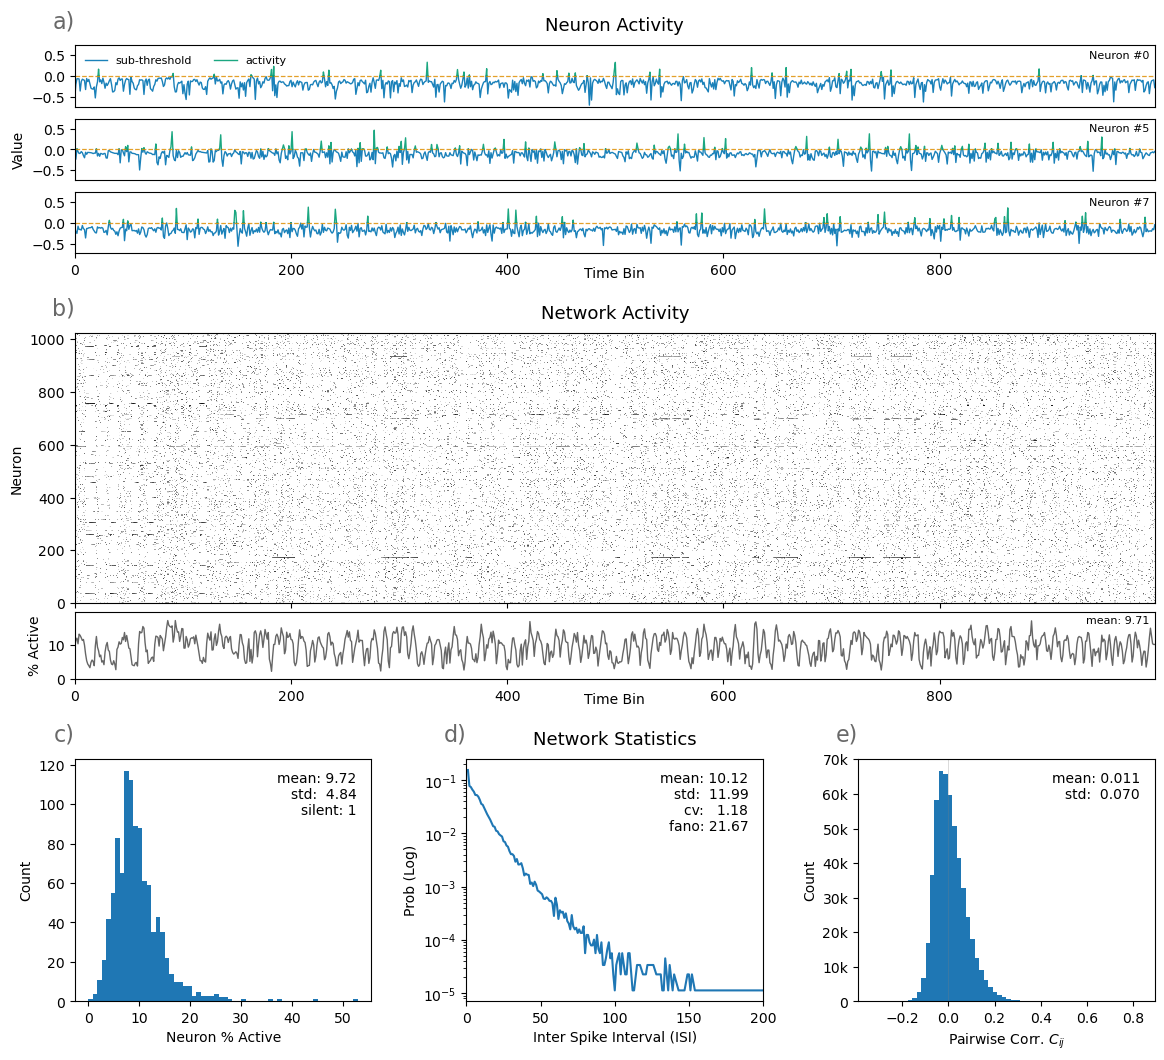

In [1]:
from pathlib import Path
import sys
import json
import warnings

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jrandom
import numpy as np

# ---------------- paths ----------------

# NOTE: YOU NEED TO FILL IN YOUR PATHS
PROJECT_ROOT = Path.cwd().resolve().parent 
DATASETS_BASE_FOLDER =Path("~/Data").expanduser().resolve()

# NOTE: ELM Network with N=1024 trained on Enwik8
MODEL_CONFIG_PATH = "model_config.json"
BEST_MODEL_PATH = "best_model_state_dict.eqx"

# ---------------- viz settings ----------------

VIZ_BATCH_SIZE = 8
VIZ_SEQ_LENGTH = 2000
BATCH_VIZ_IDX = 0
HIDDEN_LAYER_IDX = 0
LAST_NUM_STEPS = VIZ_SEQ_LENGTH // 2
EVAL_SEED = 12345

# ---------------- project imports ----------------

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.datasets.language.data_loader import get_lm_corpus
from src.datasets.language.language_viz_utils import calculate_and_plot_spiking_stats
from src.models.elm_layer import ALL_MONITORS
from src.models.elm_network import ELMNetwork
from src.training.train_utils import cast_floats

# ---------------- load dataset ----------------

dataset_path = DATASETS_BASE_FOLDER / "language_modeling" / "enwik8"
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    corpus = get_lm_corpus(str(dataset_path), "enwik8")
vocab_size = len(corpus.vocab)

viz_iterator = corpus.get_iterator(
    "test",
    VIZ_BATCH_SIZE,
    VIZ_SEQ_LENGTH,
    device="cpu",
    ext_len=0,
)
example_viz_batch = viz_iterator.get_batch(0)

# ---------------- load model ----------------
print("Loading trained model...")
      
with open(MODEL_CONFIG_PATH, "r") as f:
    model_config = json.load(f)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    model = ELMNetwork(
        **model_config,
        key=jrandom.PRNGKey(0),
    )
model = eqx.tree_deserialise_leaves(str(BEST_MODEL_PATH), model)

# ---------------- run inference ----------------
print("Running longer inference...")

eval_key = jrandom.PRNGKey(EVAL_SEED)
_, batch_viz_key = jrandom.split(eval_key, 2)

inputs = jnp.array(example_viz_batch[0].T, dtype=jnp.int32)
batch_viz_keys = jrandom.split(batch_viz_key, VIZ_BATCH_SIZE)

logits, recordings, _ = jax.vmap(
    lambda x, key: model(
        x=x,
        init_carry=None,
        key=key,
        monitor=ALL_MONITORS,
        inference=True,
    )
)(inputs, batch_viz_keys)

recordings = cast_floats(recordings, "float32")

# ---------------- extract records ----------------

hidden_layer_activity = np.array(
    recordings[HIDDEN_LAYER_IDX][0]["activity"][
        BATCH_VIZ_IDX, -LAST_NUM_STEPS:
    ]
)
hidden_neuron_preacts = np.array(
    recordings[HIDDEN_LAYER_IDX][1]["preact"][
        BATCH_VIZ_IDX, -LAST_NUM_STEPS:, :, 0
    ]
)
hidden_neuron_biases = np.array(
    model.layers[HIDDEN_LAYER_IDX].ensemble.b
).flatten()

# ---------------- show plot ----------------
print("Plotting neural activity...")
      
activity_stats = calculate_and_plot_spiking_stats(
    trace_neuron_indices=(0,5,7),
    layer_activity=hidden_layer_activity,
    neuron_outputs=hidden_neuron_preacts,
    neuron_biases=hidden_neuron_biases,
    max_interval=min(200, LAST_NUM_STEPS),
    path=None,
)
